# Electricity Demand Forecasting using AI

## TODO:
add time at create dataset

Before running this notebook, please make sure you installed the requiremented packages and libraries. For more detailled explaination about why we included certain data in the dataset or choose certain models, please take a lot in the project report which you can find in the `docs/` folder.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from lightgbm import LGBMRegressor
import warnings
from skforecast.exceptions import MissingValuesWarning, LongTrainingWarning

#from core.create_dataset import create_dataset

warnings.simplefilter('ignore', category=MissingValuesWarning)
warnings.simplefilter('ignore', category=LongTrainingWarning)

ImportError: cannot import name 'Hourly' from 'meteostat' (c:\Users\dilg\Documents\electricity-demand-forecasting\.venv\Lib\site-packages\meteostat\__init__.py)

Here, you can define all parameters used for model training and backtesting. The Dataset is split into 90% training and 10% testing. The selected `eval_metric` is shown in the plots. You can change it as needed. If you choose a different metric, you can look it up in the [Skforecast documentation](https://skforecast.org/0.15.0/user_guides/metrics) and add it to the `metrics` list of available metrics. 

`lags` defines the number of recent past values the model gets as an input. Rolling window features `window_features` are used to provide the model with historical context by summarizing most recent past observations over fixed time windows.

In [7]:
start = '2015-01-01'
train_end = '2023-12-31'
test_end = '2024-12-31'
eval_metric = 'mean_absolute_percentage_error'
metrics = ['mean_absolute_error', 'mean_squared_error', 'mean_absolute_percentage_error']
lags = 24
window_features = RollingFeatures(stats=['mean', 'std', 'min', 'max'], window_sizes=[24*3, 24*7, 24*7, 24*7])

Now, we need to create a dataset that can be used to train the model. We are using different APIs, such as `smard-api` and `digidates`, which are slow when fetching a lot of data over a long period of time due to their API design. Therefore, we have commented out the `create_dataset()` function and loaded the dataset directly instead.

In [8]:
# # create dataset
# df = create_dataset()

# load dataset
df = pd.read_csv('dataset.csv', delimiter=';')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime').sort_index()
data = df.copy()
data_train = data.loc[start:train_end].asfreq('h') # explicity annotate frequency is hourly
prediction_results, meta_results = pd.DataFrame(), pd.DataFrame()
prediction_results['actual_grid_load'] = data['grid_load'].loc[pd.to_datetime(train_end, utc=True)+pd.Timedelta(days=1):pd.to_datetime(test_end, utc=True)]

Conventional cross-validation does not make sense for time series data since the order of the values is important. Therefore, we use a TimeSeriesFold to test our data on new data that our model has not been trained on. Moreover, we start by turning off the `refit` option, since refitting our model 365/366 times for backtesting is computationally very expensive. We test the model's performance over a year and calculate the average error, but only display one week in the plot. This can be changed when calling the `plot_predictions()` function.

In [9]:
def plot_predictions(df, predictions, model_name, eval_metric, metric, start_plot='2024-03-04', end_plot='2024-03-11'):
    start_plot = pd.Timestamp(start_plot)
    end_plot = pd.Timestamp(end_plot)
    val_week = df['grid_load'].loc[predictions.index.min():predictions.index.max()]
    fig, ax = plt.subplots(figsize=(10,6))
    val_week.plot(ax=ax, label='Actual Load', color='tab:blue')
    predictions['pred'].plot(ax=ax, label='Forecast', color='tab:red')
    plt.xlim(start_plot, end_plot)
    plt.ylabel("Grid Load in MWh")
    plt.xlabel("")
    if eval_metric == 'mean_absolute_percentage_error':
        plt.title(f"{model_name} with MAPE {metric*100:.2f}% ")
    elif eval_metric == 'mean_squared_error':
        plt.title(f"{model_name} with MSE {metric:.2f} (MWh)^2 ")
    elif eval_metric == 'mean_absolute_error':
        plt.title(f"{model_name} with MAE {metric:.2f} MWh ")
    plt.grid()
    plt.legend(loc = 'upper right')
    plt.tight_layout()
    plt.show()

def backtesting(model, df, cv, test_end, metrics, exog=False):
    metric, predictions = backtesting_forecaster(
                                forecaster = model,
                                y = df.loc['2015-01-01':test_end]['grid_load'].asfreq('h'),
                                exog = df.loc['2015-01-01':test_end].drop(columns=['grid_load']) if exog else None,
                                cv = cv,
                                metric = metrics)
    return metric, predictions

# define cross-validation scheme
cv = TimeSeriesFold(steps=24, initial_train_size=len(data_train), refit=False)

When addressing a forecasting task, it is essential to first define a baseline model. A baseline serves as a simple reference, allowing the performance of more advanced models to be evaluated in a meaningful way.

This approach, often referred to as seasonal naive forecasting, predicts future values by reusing observations from the same point in a previous season—for example, the same weekday of the previous week or the same hour of the previous day.

Based on the results of the exploratory data analysis, the baseline model forecasts each hour using the value observed at the corresponding hour on the previous day.

100%|██████████| 366/366 [00:00<00:00, 412.49it/s]


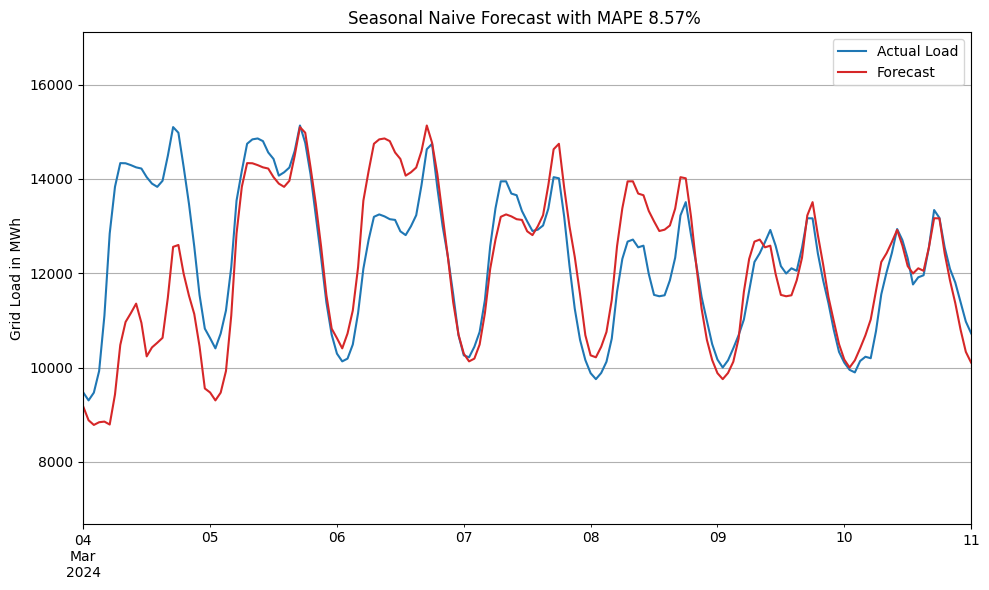

In [10]:
# seasonal naive baseline
model_baseline = ForecasterEquivalentDate(offset=pd.DateOffset(days=1), n_offsets=1)
metric, predictions = backtesting(model_baseline, data, cv, test_end, metrics)
plot_predictions(data, predictions, "Seasonal Naive Forecast", eval_metric, metric[eval_metric].values[0])

# store results
prediction_results['seasonal_naive_forecast'] = predictions['pred']
row = { "model_name": "seasonal_naive_forecast",
        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
meta_results = pd.concat([pd.DataFrame([row]), meta_results], ignore_index=True)

After establishing the baseline, we introduce a recursive LightGBM model without exogenous features to provide a more expressive reference model.

In this approach, a LightGBM regressor is trained solely on lagged values of the target time series, allowing it to learn nonlinear temporal relationships from the data itself, without relying on external information.

Forecasts are generated recursively: the model predicts the next time step based on past observations, and each prediction is then fed back as input to produce subsequent forecasts over the desired horizon.

100%|██████████| 366/366 [00:17<00:00, 21.07it/s]


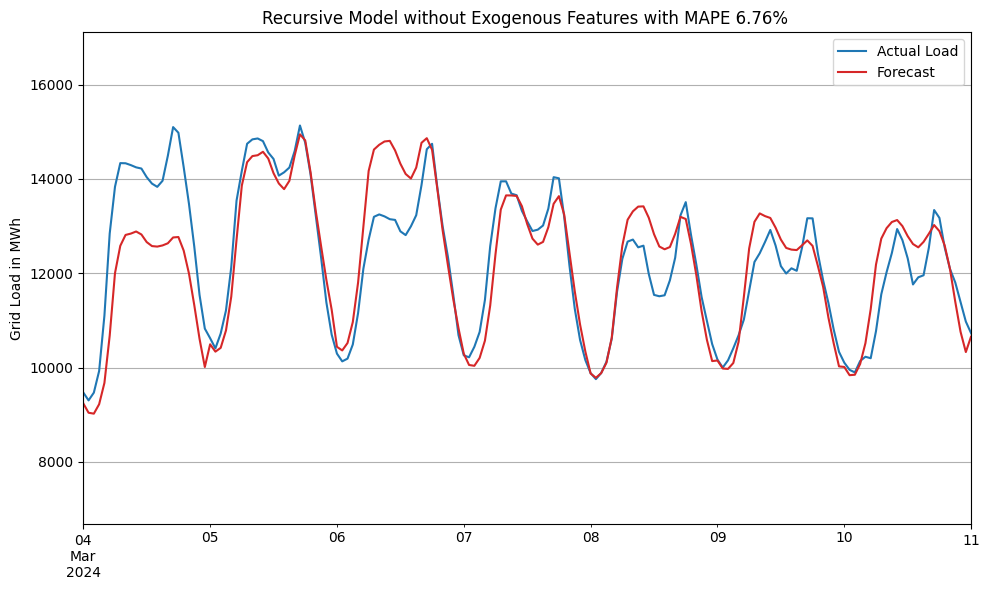

In [11]:
# recursive lgbm without exogenous features
estimator = LGBMRegressor(random_state=15926, verbose=-1)
forecaster = ForecasterRecursive(estimator=estimator, lags=lags, window_features=window_features)
metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=False)
plot_predictions(data, predictions, "Recursive Model without Exogenous Features", eval_metric, metric[eval_metric].values[0])
prediction_results['recursive_no_exog'] = predictions['pred']

# store results
prediction_results['recursive_no_exog'] = predictions['pred']
row = { "model_name": "recursive_no_exog",
        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
meta_results = pd.concat([meta_results, pd.DataFrame([row])], ignore_index=True)

As a next step, the recursive LightGBM model is extended by incorporating exogenous features, enabling the model to account not only for the internal dynamics of the time series but also for external factors that systematically influence the target variable.

100%|██████████| 366/366 [00:18<00:00, 19.41it/s]


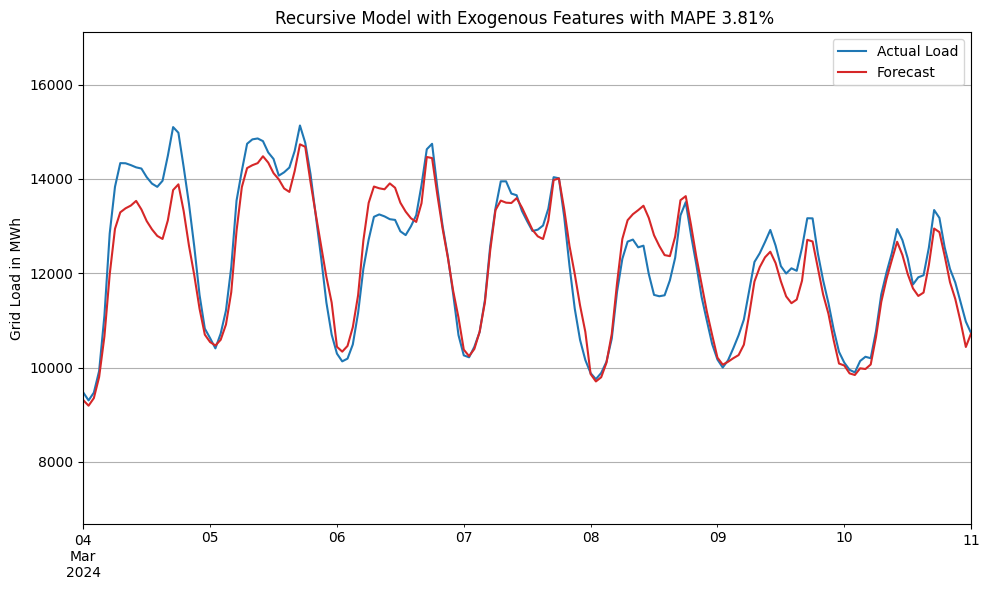

In [12]:
 # recursive lgbm with exogenous features
metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=True)
plot_predictions(data, predictions, "Recursive Model with Exogenous Features", eval_metric, metric[eval_metric].values[0])
prediction_results['recursive_with_exog'] = predictions['pred']

# store results
prediction_results['recursive_with_exog'] = predictions['pred']
row = { "model_name": "recursive_with_exog",
        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
meta_results = pd.concat([meta_results, pd.DataFrame([row])], ignore_index=True)

After tuning the LightGBM regressor using Bayesian hyperparameter optimization, the model is configured with parameter values that balance bias and variance more effectively, leading to improved predictive performance compared to default settings.

100%|██████████| 366/366 [00:30<00:00, 12.01it/s]


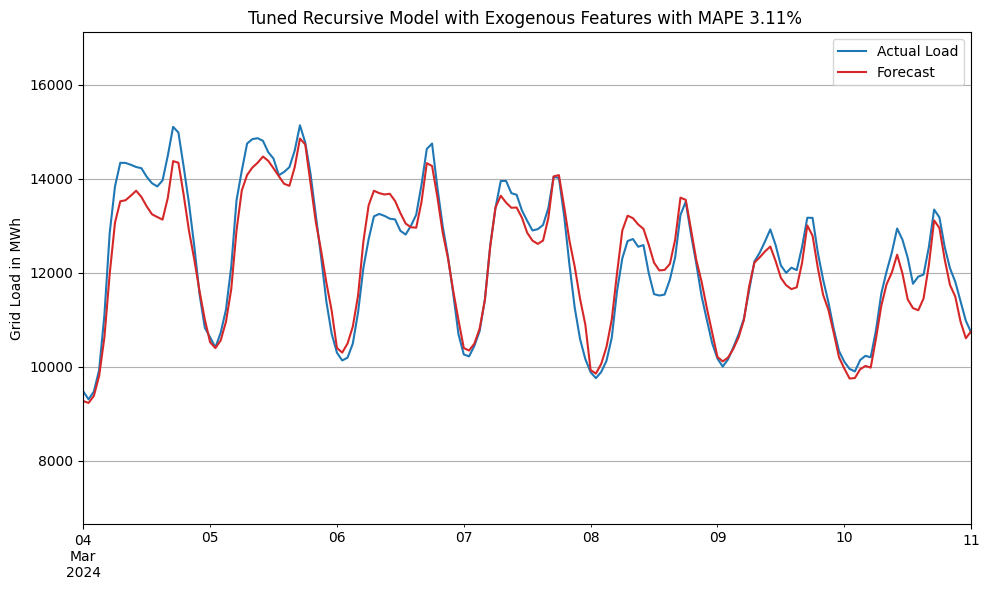

In [13]:
# tuned recursive lgbm with exogenous features
estimator = LGBMRegressor(learning_rate=0.04802270167510142, n_estimators=2900, num_leaves=166,
                            max_depth=6, min_child_samples=110, subsample=0.9404067086517863,
                            subsample_freq=1, colsample_bytree=0.6772559947743917, reg_alpha=4.588474569608268e-05,
                            reg_lambda=0.0004650965158027969,
                            random_state=15926, verbose=-1)
forecaster = ForecasterRecursive(estimator=estimator, lags=lags, window_features=window_features)
metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=True)
plot_predictions(data, predictions, "Tuned Recursive Model with Exogenous Features", eval_metric, metric[eval_metric].values[0])
prediction_results['tuned_recursive_with_exog'] = predictions['pred']

# store results
prediction_results['tuned_recursive_with_exog'] = predictions['pred']
row = { "model_name": "tuned_recursive_with_exog",
        "mean_absolute_percentage_error": metric["mean_absolute_percentage_error"].iloc[0],
        "mean_absolute_error": metric["mean_absolute_error"].iloc[0],
        "mean_squared_error": metric["mean_squared_error"].iloc[0]}
meta_results = pd.concat([meta_results, pd.DataFrame([row])], ignore_index=True)

In this backtesting setup, `refit=True` is used, meaning the model is retrained at each forecasting step using all data available up to that point. This differs from standard cross-validation, where the model is typically trained once per fold on randomly sampled data.

Here, the training window grows sequentially while preserving the temporal order of the time series. As a result, the model is repeatedly fitted on increasingly larger historical datasets before generating predictions, yielding a more realistic evaluation of forecasting performance at the cost of substantially increased computational time and CPU load (3:16h, Dell).

100%|██████████| 366/366 [3:16:10<00:00, 32.16s/it]  


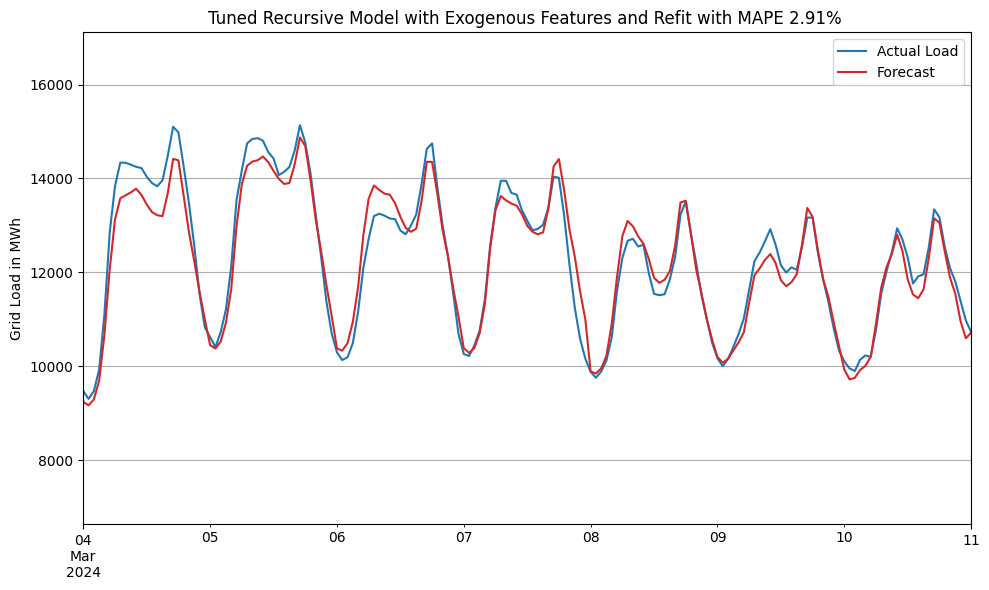

In [14]:
# tuned recursive lgbm with exogenous features and refit
cv = TimeSeriesFold(steps=24, initial_train_size=len(data_train), refit=True)
estimator = LGBMRegressor(learning_rate=0.04802270167510142, n_estimators=2900, num_leaves=166,
                            max_depth=6, min_child_samples=110, subsample=0.9404067086517863,
                            subsample_freq=1, colsample_bytree=0.6772559947743917, reg_alpha=4.588474569608268e-05,
                            reg_lambda=0.0004650965158027969,
                            random_state=15926, verbose=-1)
forecaster = ForecasterRecursive(estimator=estimator, lags=lags, window_features=window_features)
metric, predictions = backtesting(forecaster, data, cv, test_end, metrics, exog=True)
plot_predictions(data, predictions, "Tuned Recursive Model with Exogenous Features and Refit", eval_metric, metric[eval_metric].values[0])
prediction_results['tuned_recursive_with_exog_refit'] = predictions['pred']